<a href="https://colab.research.google.com/github/actelleza-maker/Ciencia-de-datos-con-IA/blob/main/Copia_de_Challenge_Conversi%C3%B3n_de_grados_Celsius_a_Fahrenheit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Challenge:*** Conversión de grados Celsius a Fahrenheit.

Dados los siguientes datos:

<div class="instructions"><div class="inner">
<div class="devsite-table-wrapper">
  <table class="vertical-rules">
    <tbody>
      <tr>
        <td colspan="1" rowspan="1"><p>Celsius:</p></td>
        <td colspan="1" rowspan="1"><p>-40.0</p></td>
        <td colspan="1" rowspan="1"><p>-10.0</p></td>
        <td colspan="1" rowspan="1"><p>0.0</p></td>
        <td colspan="1" rowspan="1"><p>8.0</p></td>
        <td colspan="1" rowspan="1"><p>15.0</p></td>
        <td colspan="1" rowspan="1"><p>22.0</p></td>
        <td colspan="1" rowspan="1"><p>38.0</p></td>
      </tr>
      <tr>
        <td colspan="1" rowspan="1"><p>Fahrenheit:</p></td>
        <td colspan="1" rowspan="1"><p>-40.0</p></td>
        <td colspan="1" rowspan="1"><p>14.0</p></td>
        <td colspan="1" rowspan="1"><p>32.0</p></td>
        <td colspan="1" rowspan="1"><p>46.0</p></td>
        <td colspan="1" rowspan="1"><p>59.0</p></td>
        <td colspan="1" rowspan="1"><p>72.0</p></td>
        <td colspan="1" rowspan="1"><p>100.0</p></td>
      </tr>
    </tbody>
  </table>
</div>
</div></div>

Visualice los datos a través de un gráfico para analizar el comportamiento de una regresión lineal con los datos en **Celsius** y **Fahrenheit**.

$Recordando$ $la$ $ecuación$ $para$ $la$ $conversión$ $de$ $grados$ $Celcius$ $a$ $Fahrenheit:$

$
F° = C°*1.8 + 32
$

Entrene una red neuronal para predecir los datos siguientes, recordando que, la infraestructura de prueba, espera un modelo entrenado que acepte una forma de entrada de [1].

Realice un test de entrenamiento para verificar las epocas dadas y visualice el comportamiento de las perdidas según el algoritmo utilizado.  

Guarde el modelo anterior en un archivo con el nombre y tipo de dato **mymodel.h5**

In [ ]:
# Importar librerias

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [ ]:
# Cargar datos

xs = np.array([-40.0, -10.0, 0.0, 8.0, 15.0, 22.0, 38.0], dtype=float)
ys = np.array([-40.0, 14.0, 32.0, 46.0, 59.0, 72.0, 100.0], dtype=float)
print(f'xs = {xs}, ys = {ys}')


xs = [-40. -10.   0.   8.  15.  22.  38.], ys = [-40.  14.  32.  46.  59.  72. 100.]


### Escalado de Datos

Es fundamental escalar los datos de entrada y salida para redes neuronales. Esto ayuda a prevenir gradientes que explotan (lo que causa `loss: nan` o `loss: inf`) y asegura que el proceso de optimización sea más estable y rápido. Utilizaremos `StandardScaler` para estandarizar `xs` y `ys`.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Crear escaladores para xs y ys
xs_scaler = StandardScaler()
ys_scaler = StandardScaler()

# Escalar xs
xs_scaled = xs_scaler.fit_transform(xs.reshape(-1, 1))

# Escalar ys
ys_scaled = ys_scaler.fit_transform(ys.reshape(-1, 1))

print('xs original:', xs)
print('xs escalado:', xs_scaled.flatten())
print('ys original:', ys)
print('ys escalado:', ys_scaled.flatten())

xs original: [-40. -10.   0.   8.  15.  22.  38.]
xs escalado: [-1.92894084 -0.63476328 -0.20337076  0.14174326  0.44371802  0.74569278
  1.43592082]
ys original: [-40.  14.  32.  46.  59.  72. 100.]
ys escalado: [-1.92973507 -0.63410477 -0.20222801  0.13367614  0.44558714  0.75749814
  1.42930644]


In [ ]:
# Regresión lineal

regresion_lineal = np.polyfit(xs, ys, 1)
# y = b0x + b1
# beta --> b0 y alfa --> b1
beta, alfa = regresion_lineal
print(f'y = {round(beta, 1)}x + {round(alfa, 1)}')

y = 1.8x + 32.0


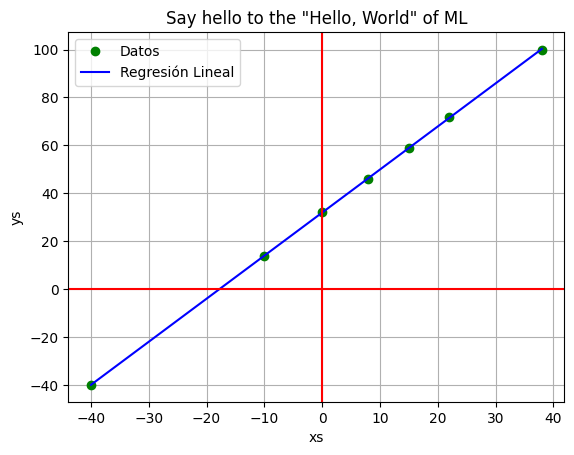

In [ ]:
# Graficar datos y regresión

plt.plot(xs, ys, 'o', color='green', label='Datos')
plt.plot(xs, beta*xs + alfa, color='blue', label='Regresión Lineal')
plt.axhline(y = 0, color = 'red')
plt.axvline(x = 0, color = 'red')
plt.title('Say hello to the "Hello, World" of ML')
plt.xlabel('xs')
plt.ylabel('ys')
plt.legend()
plt.grid()
plt.show()

In [ ]:
import tensorflow as tf

# Perceptron simple

capa = tf.keras.layers.Dense(units=1)
modelo = tf.keras.Sequential([
    tf.keras.Input(shape=(1,)),
    capa
  ])

# Compile the model with a lower learning rate for SGD
modelo.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01), loss='mse')

# Display model summary to check its architecture
modelo.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Re-inicializar y compilar el modelo para asegurar pesos frescos con datos escalados
capa = tf.keras.layers.Dense(units=1)
modelo = tf.keras.Sequential([
    tf.keras.Input(shape=(1,)),
    capa
  ])

# Compile the model with the same lower learning rate for SGD
modelo.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01), loss='mse')

modelo.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Entrenando la red

print('Comenzando entrenamiento...')
historial = modelo.fit(xs escalado, ys escalado, epochs=100, verbose=True)
print('Entrenamiento finalizado')

SyntaxError: invalid syntax. Perhaps you forgot a comma? (2275076626.py, line 4)

Comenzando entrenamiento con datos escalados...
Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - loss: 0.0041
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0039
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0037
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0036
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0035
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0033
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0032
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0031
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0029
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0028
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0027
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0026
Epoch 13/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0025
Epoch 14/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0024
Epoch 15/500
1/1 ━━━━━━━━━━━━━━━━━━━

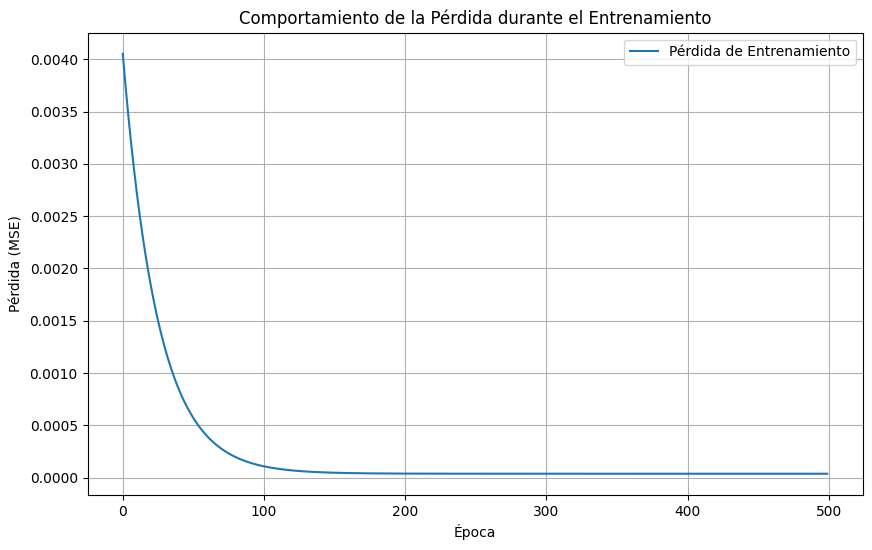

In [ ]:
# Entrenando la red con datos escalados

print('Comenzando entrenamiento con datos escalados...')
historial = modelo.fit(xs_scaled, ys_scaled, epochs=500, verbose=True) # Aumentar epochs para mejor convergencia con datos escalados
print('Entrenamiento finalizado')

# Graficar el historial de pérdidas
plt.figure(figsize=(10, 6))
plt.plot(historial.history['loss'], label='Pérdida de Entrenamiento')
plt.title('Comportamiento de la Pérdida durante el Entrenamiento')
plt.xlabel('Época')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Realizar una prueba de predicción y visualizar el resultado
# Predecir un valor de Celsius (escalado)

# Ejemplo: 100 grados Celsius
cel_test = np.array([100.0])
cel_test_scaled = xs_scaler.transform(cel_test.reshape(-1, 1))

# Realizar la predicción con el modelo
prediction_scaled = modelo.predict(cel_test_scaled)

# Des-escalar la predicción para obtener el valor en Fahrenheit real
prediction_fahrenheit = ys_scaler.inverse_transform(prediction_scaled)

print(f'{cel_test[0]} grados Celsius son aproximadamente {prediction_fahrenheit[0][0]:.2f} grados Fahrenheit.')

# Comparar con la fórmula real
real_fahrenheit = cel_test[0] * 1.8 + 32
print(f'Según la fórmula, {cel_test[0]} grados Celsius son {real_fahrenheit:.2f} grados Fahrenheit.')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
100.0 grados Celsius son aproximadamente 211.74 grados Fahrenheit.
Según la fórmula, 100.0 grados Celsius son 212.00 grados Fahrenheit.


In [ ]:
# Guardar el modelo
modelo.save('mymodel.h5')
print('Modelo guardado como mymodel.h5')

Modelo guardado como mymodel.h5
